In [1]:
import torch

activation_mask_48 = torch.load("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run3/Masks/0.0%Pruned/Cluster3masks.pt")
activation_mask_59 = torch.load("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run3/Masks/59.04%Pruned/Cluster3masks.pt")

In [2]:
activation_mask_48.shape

torch.Size([1024, 10000])

In [3]:
def iou(m1,m2):
    ious = []
    for neuronm1, neuronm2 in zip(m1,m2):
        intersection = (neuronm1 & neuronm2).sum().item()  
        union = (neuronm1 | neuronm2).sum().item()
        ious.append(intersection/union)
    return sum(ious)/len(ious)

In [4]:
import matplotlib.pyplot as plt
def plot(root, results):
    """
    Create three plots, each highlighting a different cluster's min/max range
    
    Parameters:
    - method: str, title prefix for the plots
    - alignment_changes: tuple of (c1, c2, c3) dictionaries with alignment values
    - mins: tuple of (min1, min2, min3) dictionaries with minimum values
    - maxs: tuple of (max1, max2, max3) dictionaries with maximum values
    """
    c1 = results['Cluster1']
    c2 = results['Cluster2']
    c3 = results['Cluster3']
   
    
    # Define cluster colors for consistency
    colors = {'c1': 'blue', 'c2': 'orange', 'c3': 'green'}
    markers = {'c1': 'o', 'c2': 's', 'c3': '^'}
    
    def create_single_plot():
        plt.figure(figsize=(10, 6))
        
        # Plot all three lines
        plt.plot(list(c1.keys()), list(c1.values()), 
                label='Cluster 1', marker=markers['c1'], color=colors['c1'])
        plt.plot(list(c2.keys()), list(c2.values()), 
                label='Cluster 2', marker=markers['c2'], color=colors['c2'])
        plt.plot(list(c3.keys()), list(c3.values()), 
                label='Cluster 3', marker=markers['c3'], color=colors['c3'])
        
        # Customize the plot
        plt.xlabel('Pruned %')
        plt.ylabel('Overlap')
        plt.title(f'{root}: Activation Mask IOU')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.margins(x=0.05)
        plt.tight_layout()
        plt.show()
    
    # Create three plots, each highlighting a different cluster
    create_single_plot()

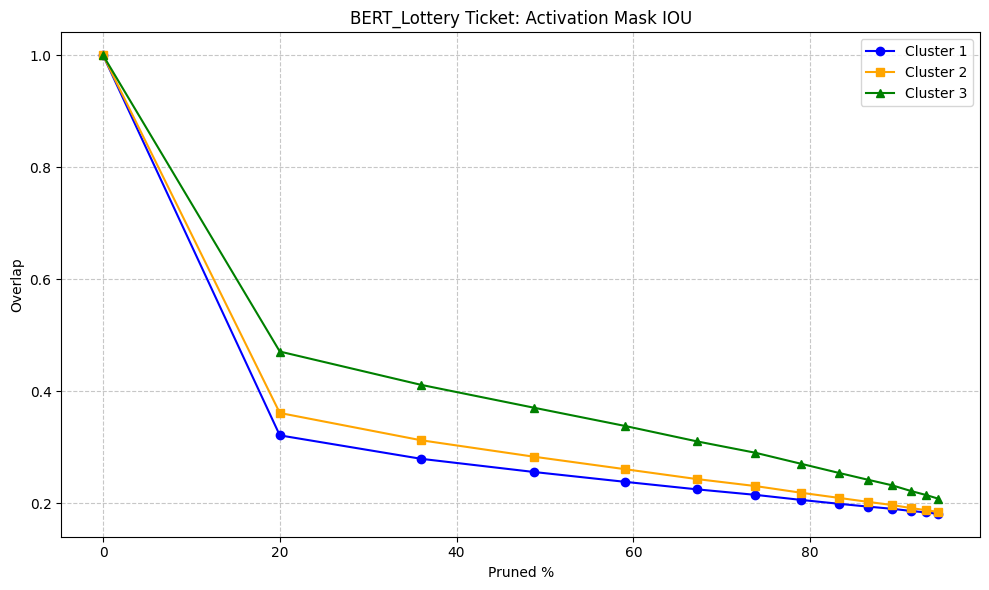

In [6]:
import os
from collections import defaultdict

roots=["/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run3/Masks/","/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run2Full/Masks" ]
results = defaultdict(lambda: defaultdict(int))

for root in roots:
    
    for i in range(3):
        activation_mask_base = torch.load( os.path.join(root, '0.0%Pruned', f'Cluster{i+1}masks.pt'), map_location='cpu')
        for pruned_folder in os.listdir(root):
            if '.ipy' in pruned_folder: continue
            
            percent = float(pruned_folder.split("%")[0])
            activation_mask_pruned = torch.load(os.path.join(root, pruned_folder, f'Cluster{i+1}masks.pt'), map_location='cpu')
            iou_am = iou(activation_mask_base,activation_mask_pruned)
            results[f'Cluster{i+1}'][percent] += iou_am
for cluster, data in results.items():
    for percent,ious in data.items():
        results[cluster][percent] = ious/len(roots)
plot('BERT_Lottery Ticket', results)
    

In [ ]:
import os
from collections import defaultdict

roots=["/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run3/Masks/","/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run2Full/Masks" ]
results = defaultdict(lambda: defaultdict(int))

for root in roots:
    
    for i in range(3):
        activation_mask_base = torch.load( os.path.join(root, '0.0%Pruned', f'Cluster{i+1}masks.pt'), map_location='cpu')
        for pruned_folder in os.listdir(root):
            if '.ipy' in pruned_folder: continue
            
            percent = float(pruned_folder.split("%")[0])
            activation_mask_pruned = torch.load(os.path.join(root, pruned_folder, f'Cluster{i+1}masks.pt'), map_location='cpu')
            iou_am = iou(activation_mask_base,activation_mask_pruned)
            results[f'Cluster{i+1}'][percent] += iou_am
for cluster, data in results.items():
    for percent,ious in data.items():
        results[cluster][percent] = ious/len(roots)
plot('BERT_Lottery Ticket', results)
    